# ============================================================
# SESIÓN 4: ACTIVIDAD - OPTIMIZACIÓN DE PARÁMETROS TDA
# ============================================================
### Objetivo: Explorar diferentes configuraciones de
### parámetros para encontrar la combinación óptima que maximice
### la mejora del TDA en forecasting de precios de berries.
#

### 1. Responde las preguntas en cada sección 
### 2. Modifica los parámetros en las celdas de experimentos
### 3. Compara resultados y saca conclusiones
### 4. No se entrega pero este ya será la base de su entregable final junto a su reporte. 
# ============================================================
**Autor:** Dr. Hugo García Tecocoatzi 

In [1]:
# ============================================================
#  CONFIGURACIÓN INICIAL 
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# TDA
from gtda.time_series import SingleTakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


Total de registros: 215
Periodo: 2008-06-01T00:00:00.000000 a 2026-04-01T00:00:00.000000

Estadísticas básicas:
  Media: 142.47
  Std: 44.71
  Min: 69.20
  Max: 299.38


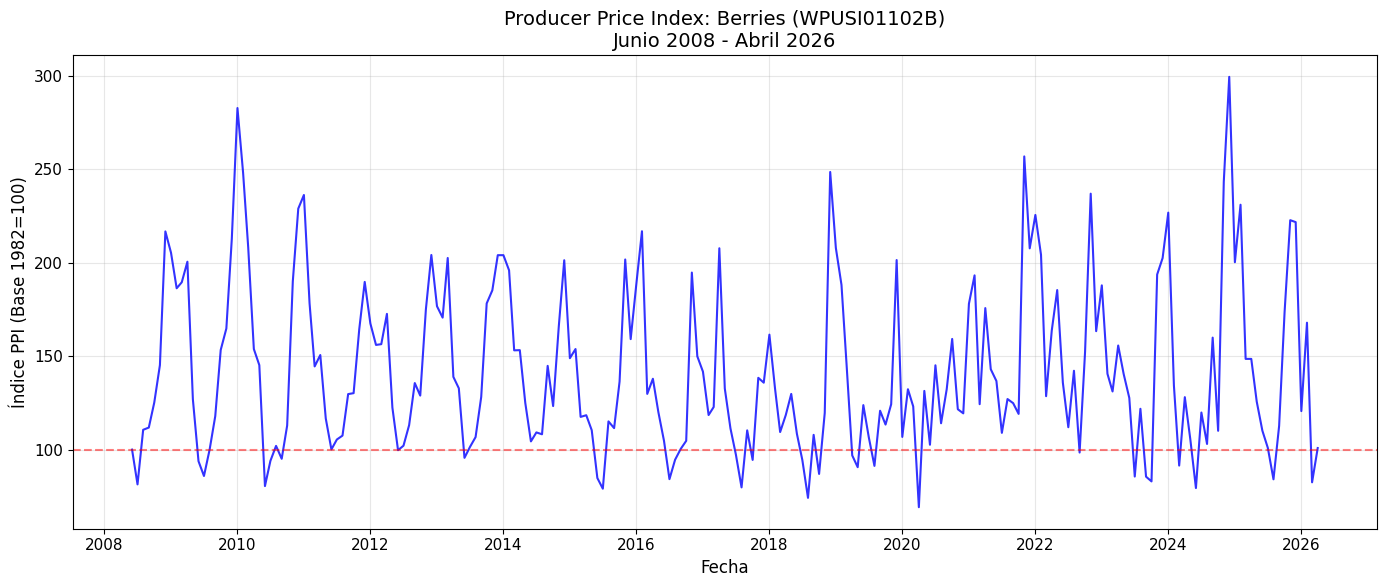

In [2]:
# ============================================================
# CARGAR  Y VISUALIZAR DE DATOS
# ============================================================

df = pd.read_csv('WPUSI01102B.csv', parse_dates=['observation_date'])
precios = df['WPUSI01102B'].values.astype(float)
fechas = df['observation_date'].values

print(f"Total de registros: {len(precios)}")
print(f"Periodo: {fechas[0]} a {fechas[-1]}")
print(f"\nEstadísticas básicas:")
print(f"  Media: {precios.mean():.2f}")
print(f"  Std: {precios.std():.2f}")
print(f"  Min: {precios.min():.2f}")
print(f"  Max: {precios.max():.2f}")

# Visualización de la serie completa
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(fechas, precios, 'b-', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Índice PPI (Base 1982=100)', fontsize=12)
ax.set_title('Producer Price Index: Berries (WPUSI01102B)\nJunio 2008 - Abril 2026', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Base 1982=100')
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
#  PREGUNTAS INICIAL SOBRE LOS DATOS
# ============================================================

print("="*80)
print("PREGUNTAS: ANÁLISIS DE LA SERIE")
print("="*80)

print("""
Observa el gráfico de la serie de precios de berries y responde:

1. ¿Qué patrón estacional observas? ¿En qué meses parecen ocurrir los picos?

2. ¿Cuál es el rango aproximado de precios? ¿Ha habido tendencia al alza?

3. ¿Qué periodos muestran mayor volatilidad?

4. ¿Por qué crees que predecir esta serie puede ser un desafío?

 
""")

PREGUNTAS: ANÁLISIS DE LA SERIE

Observa el gráfico de la serie de precios de berries y responde:

1. ¿Qué patrón estacional observas? ¿En qué meses parecen ocurrir los picos?

2. ¿Cuál es el rango aproximado de precios? ¿Ha habido tendencia al alza?

3. ¿Qué periodos muestran mayor volatilidad?

4. ¿Por qué crees que predecir esta serie puede ser un desafío?





Periodo de entrenamiento: 2013-2019 (84 meses)
Periodo de prueba: 2020-2022 (36 meses)


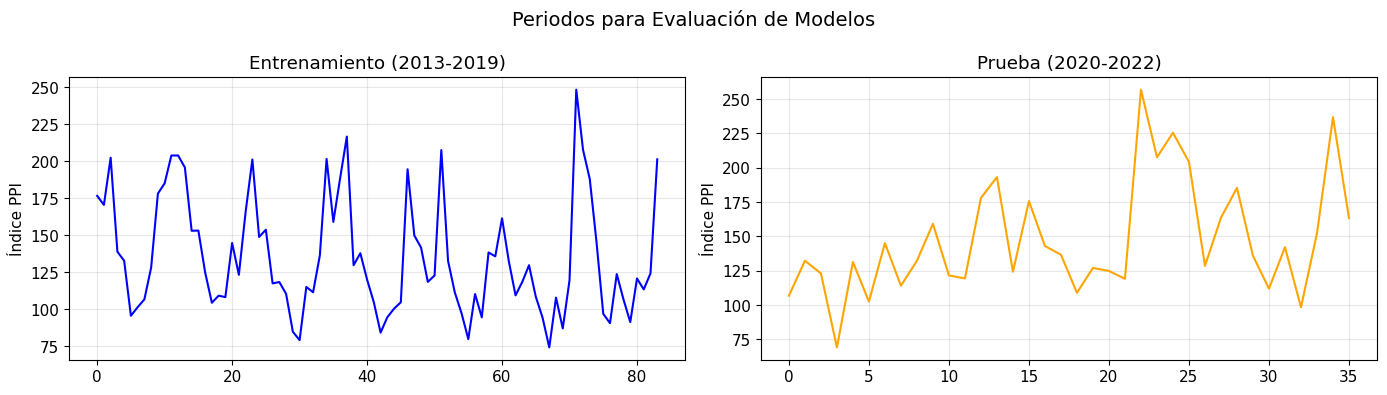

In [4]:
# ============================================================
# 4. DEFINICIÓN DE PERIODOS PARA EVALUACIÓN 
# ============================================================

periodos_entrenamiento = {
    '2008-2012': ('2008-06-01', '2012-12-31'),
    '2013-2019': ('2013-01-01', '2019-12-31'),
    '2020-2022': ('2020-01-01', '2022-12-31'),
    '2023-2024': ('2023-01-01', '2024-12-31')
}

def extraer_datos_por_fecha(inicio, fin):
    if inicio is None:
        mask = np.ones(len(precios), dtype=bool)
    else:
        mask = (fechas >= np.datetime64(inicio)) & (fechas <= np.datetime64(fin))
    return precios[mask], fechas[mask]

# Para los experimentos usaremos un periodo fijo, por ejemplo:
signal_entreno, _ = extraer_datos_por_fecha('2013-01-01', '2019-12-31')
signal_prueba, _ = extraer_datos_por_fecha('2020-01-01', '2022-12-31')

print(f"Periodo de entrenamiento: 2013-2019 ({len(signal_entreno)} meses)")
print(f"Periodo de prueba: 2020-2022 ({len(signal_prueba)} meses)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(signal_entreno, 'b-', linewidth=1.5)
axes[0].set_title('Entrenamiento (2013-2019)')
axes[0].set_ylabel('Índice PPI')
axes[0].grid(True, alpha=0.3)

axes[1].plot(signal_prueba, 'orange', linewidth=1.5)
axes[1].set_title('Prueba (2020-2022)')
axes[1].set_ylabel('Índice PPI')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Periodos para Evaluación de Modelos', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# FUNCIÓN BASE PARA FORECASTING 
# ============================================================

def entrenar_y_evaluar(signal_entreno, signal_prueba, 
                       window_size=24, embedding_dim=6, time_delay=3,
                       use_tda=True):
    """
    Entrena un modelo y evalúa en periodo de prueba.
    
    Parámetros:
    - window_size: tamaño de la ventana deslizante (meses)
    - embedding_dim: dimensión del embedding de Takens
    - time_delay: retardo del embedding
    - use_tda: si usar características topológicas
    
    Retorna:
    - mae: Error Absoluto Medio
    - rmse: Raíz del Error Cuadrático Medio
    - r2: Coeficiente de Determinación
    - mejora: mejora porcentual vs baseline (si use_tda=True)
    """
    
    # Sliding window para entrenamiento
    SW = SlidingWindow(size=window_size, stride=1)
    X_signal = signal_entreno.reshape(-1, 1)
    X_windows, y_train = SW.fit_transform_resample(X_signal, signal_entreno)
    
    if use_tda:
        # Extraer características topológicas
        STE = SingleTakensEmbedding(
            parameters_type="fixed",
            dimension=embedding_dim,
            time_delay=time_delay
        )
        VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1, collapse_edges=True)
        
        topo_features = []
        for i in range(X_windows.shape[0]):
            window_1d = X_windows[i].flatten()
            try:
                embedding = STE.fit_transform(window_1d)
                if len(embedding) >= 5:
                    diagrams = VR.fit_transform([embedding])[0]
                    mask = diagrams[:, 2] == 1
                    if np.any(mask):
                        persistences = diagrams[mask, 1] - diagrams[mask, 0]
                        max_pers = np.max(persistences)
                        mean_pers = np.mean(persistences)
                        std_pers = np.std(persistences)
                        n_cycles = len(persistences)
                    else:
                        max_pers = mean_pers = std_pers = n_cycles = 0
                    topo_features.append([max_pers, mean_pers, std_pers, n_cycles])
                else:
                    topo_features.append([0, 0, 0, 0])
            except:
                topo_features.append([0, 0, 0, 0])
        
        topo_features = np.array(topo_features)
        
        # Normalizar y combinar
        scaler_raw = StandardScaler()
        scaler_topo = StandardScaler()
        X_raw_norm = scaler_raw.fit_transform(X_windows.reshape(-1, window_size))
        X_topo_norm = scaler_topo.fit_transform(topo_features)
        X_train = np.hstack([X_raw_norm, X_topo_norm])
    else:
        X_train = X_windows.reshape(-1, window_size)
        scaler_raw = StandardScaler()
        X_train = scaler_raw.fit_transform(X_train)
    
    # Entrenar Random Forest
    rf = RandomForestRegressor(n_estimators=200, max_depth=10, 
                               min_samples_split=5, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    # Predicción recursiva
    preds = []
    current_window = signal_entreno[-window_size:].copy()
    
    for i in range(len(signal_prueba)):
        if use_tda:
            try:
                STE_pred = SingleTakensEmbedding(
                    parameters_type="fixed", dimension=embedding_dim, time_delay=time_delay)
                VR_pred = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1, collapse_edges=True)
                
                embedding = STE_pred.fit_transform(current_window)
                if len(embedding) >= 5:
                    diagrams = VR_pred.fit_transform([embedding])[0]
                    mask = diagrams[:, 2] == 1
                    if np.any(mask):
                        persistences = diagrams[mask, 1] - diagrams[mask, 0]
                        max_pers = np.max(persistences)
                        mean_pers = np.mean(persistences)
                        std_pers = np.std(persistences)
                        n_cycles = len(persistences)
                    else:
                        max_pers = mean_pers = std_pers = n_cycles = 0
                    topo_feat = np.array([max_pers, mean_pers, std_pers, n_cycles]).reshape(1, -1)
                else:
                    topo_feat = np.array([[0, 0, 0, 0]])
                
                current_raw_norm = scaler_raw.transform(current_window.reshape(1, -1))
                current_topo_norm = scaler_topo.transform(topo_feat)
                x_pred = np.hstack([current_raw_norm, current_topo_norm])
            except:
                x_pred = scaler_raw.transform(current_window.reshape(1, -1))
        else:
            x_pred = scaler_raw.transform(current_window.reshape(1, -1))
        
        pred = rf.predict(x_pred)[0]
        preds.append(pred)
        
        if i < len(signal_prueba) - 1:
            current_window = np.roll(current_window, -1)
            current_window[-1] = signal_prueba[i]
    
    mae = mean_absolute_error(signal_prueba, preds)
    rmse = np.sqrt(mean_squared_error(signal_prueba, preds))
    r2 = r2_score(signal_prueba, preds)
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'preds': preds}

print("✅ Función de entrenamiento y evaluación definida")

✅ Función de entrenamiento y evaluación definida


📊 EXPERIMENTO BASE: Modelo SIN Características Topológicas

🔹 Resultados Baseline (sin TDA):
   MAE:  37.6931
   RMSE: 48.1850
   R²:   -0.3799


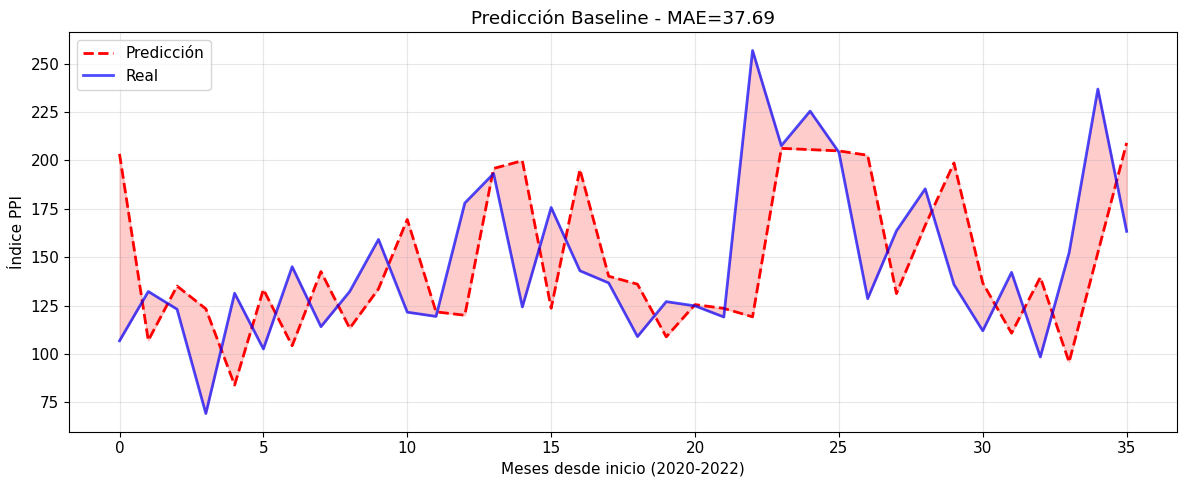

In [6]:
# ============================================================
# EXPERIMENTO BASE: SIN TDA (BASELINE)
# ============================================================

print("="*80)
print("📊 EXPERIMENTO BASE: Modelo SIN Características Topológicas")
print("="*80)

# Ejecutar baseline
resultado_base = entrenar_y_evaluar(signal_entreno, signal_prueba, 
                                    window_size=24, use_tda=False)

print(f"\n🔹 Resultados Baseline (sin TDA):")
print(f"   MAE:  {resultado_base['mae']:.4f}")
print(f"   RMSE: {resultado_base['rmse']:.4f}")
print(f"   R²:   {resultado_base['r2']:.4f}")

# Visualizar predicción
plt.figure(figsize=(12, 5))
plt.plot(resultado_base['preds'], 'r--', label='Predicción', linewidth=2)
plt.plot(signal_prueba, 'b-', label='Real', linewidth=2, alpha=0.7)
plt.fill_between(range(len(signal_prueba)), signal_prueba, resultado_base['preds'], alpha=0.2, color='red')
plt.xlabel('Meses desde inicio (2020-2022)')
plt.ylabel('Índice PPI')
plt.title(f'Predicción Baseline - MAE={resultado_base["mae"]:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
#  ¿QUÉ PARÁMETROS DEBEMOS OPTIMIZAR?
# ============================================================

print("="*80)
print("PREGUNTA: PARÁMETROS CLAVE DEL TDA")
print("="*80)

print("""
El TDA introduce nuevos parámetros que debemos ajustar:

1. WINDOW_SIZE (tamaño de ventana):
   - ¿Cuántos puntos del pasado usamos para predecir?
   - ¿Cuál es el ciclo natural de los precios de berries?
   - Prueba: 6, 12, 18, 24, 36 meses

2. EMBEDDING_DIM (dimensión del embedding):
   - ¿Cuántos retardos usamos en el embedding?
   - Regla: debe ser menor que window_size/3
   - Prueba: 2, 3, 4, 5

3. TIME_DELAY (retardo entre puntos):
   - ¿Qué separación entre puntos del embedding?
   - Para datos mensuales, τ=1 o τ=2 debería ser óptimo

REFLEXIÓN:
   ¿Qué esperas que pase si usas una ventana demasiado pequeña?
   ¿Y si usas una ventana demasiado grande?
   ¿Qué relación hay entre embedding_dim y window_size?


""")

PREGUNTA: PARÁMETROS CLAVE DEL TDA

El TDA introduce nuevos parámetros que debemos ajustar:

1. WINDOW_SIZE (tamaño de ventana):
   - ¿Cuántos puntos del pasado usamos para predecir?
   - ¿Cuál es el ciclo natural de los precios de berries?
   - Prueba: 6, 12, 18, 24, 36 meses

2. EMBEDDING_DIM (dimensión del embedding):
   - ¿Cuántos retardos usamos en el embedding?
   - Regla: debe ser menor que window_size/3
   - Prueba: 2, 3, 4, 5

3. TIME_DELAY (retardo entre puntos):
   - ¿Qué separación entre puntos del embedding?
   - Para datos mensuales, τ=1 o τ=2 debería ser óptimo

REFLEXIÓN:
   ¿Qué esperas que pase si usas una ventana demasiado pequeña?
   ¿Y si usas una ventana demasiado grande?
   ¿Qué relación hay entre embedding_dim y window_size?





🔬 ACTIVIDAD 1: ¿CUÁL ES EL MEJOR TAMAÑO DE VENTANA?

Probando diferentes window_sizes (embedding_dim=4, τ=1):
------------------------------------------------------------

Probando window_size = 6 meses...
   Baseline MAE: 37.7707
   TDA MAE:      37.6283
   Mejora:       +0.38%

Probando window_size = 12 meses...
   Baseline MAE: 37.3843
   TDA MAE:      37.0737
   Mejora:       +0.83%

Probando window_size = 18 meses...
   Baseline MAE: 37.4852
   TDA MAE:      37.1575
   Mejora:       +0.87%

Probando window_size = 24 meses...
   Baseline MAE: 37.6931
   TDA MAE:      37.8869
   Mejora:       -0.51%

Probando window_size = 30 meses...
   Baseline MAE: 37.0876
   TDA MAE:      37.2702
   Mejora:       -0.49%

Probando window_size = 36 meses...
   Baseline MAE: 37.3375
   TDA MAE:      37.2433
   Mejora:       +0.25%


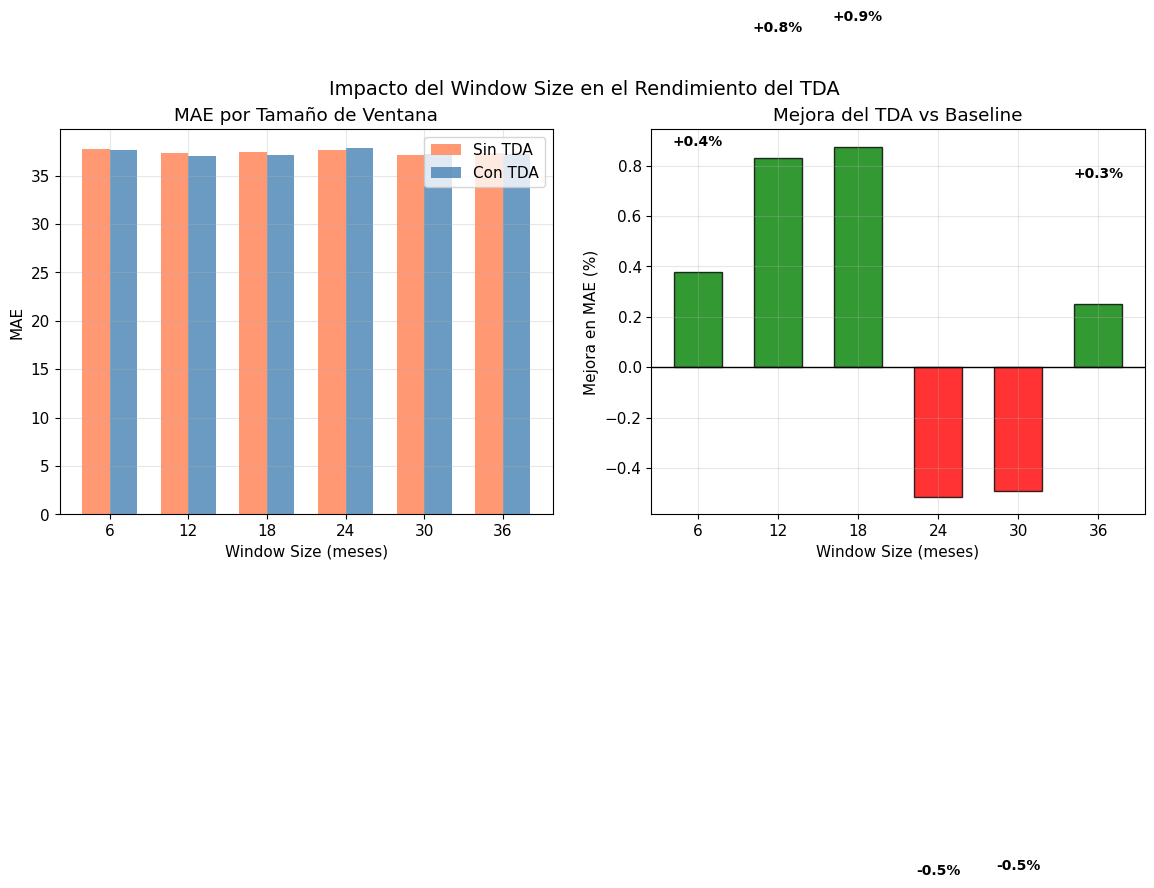

In [8]:
# ============================================================
# ACTIVIDAD 1: EXPLORAR DIFERENTES WINDOW_SIZES
# ============================================================

print("="*80)
print("🔬 ACTIVIDAD 1: ¿CUÁL ES EL MEJOR TAMAÑO DE VENTANA?")
print("="*80)

# Valores a explorar
window_sizes = [6, 12, 18, 24, 30, 36]
resultados_windows = []

print("\nProbando diferentes window_sizes (embedding_dim=4, τ=1):")
print("-"*60)

for ws in window_sizes:
    print(f"\nProbando window_size = {ws} meses...")
    
    # Baseline para este window_size
    base = entrenar_y_evaluar(signal_entreno, signal_prueba, 
                              window_size=ws, use_tda=False)
    
    # Con TDA
    tda = entrenar_y_evaluar(signal_entreno, signal_prueba,
                             window_size=ws, embedding_dim=4, time_delay=1,
                             use_tda=True)
    
    mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
    
    resultados_windows.append({
        'window': ws,
        'baseline_mae': base['mae'],
        'tda_mae': tda['mae'],
        'mejora': mejora
    })
    
    print(f"   Baseline MAE: {base['mae']:.4f}")
    print(f"   TDA MAE:      {tda['mae']:.4f}")
    print(f"   Mejora:       {mejora:+.2f}%")

# Visualizar resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

windows_vals = [r['window'] for r in resultados_windows]
baseline_maes = [r['baseline_mae'] for r in resultados_windows]
tda_maes = [r['tda_mae'] for r in resultados_windows]
mejoras = [r['mejora'] for r in resultados_windows]

x = np.arange(len(windows_vals))
width = 0.35

ax1 = axes[0]
ax1.bar(x - width/2, baseline_maes, width, label='Sin TDA', color='coral', alpha=0.8)
ax1.bar(x + width/2, tda_maes, width, label='Con TDA', color='steelblue', alpha=0.8)
ax1.set_xlabel('Window Size (meses)')
ax1.set_ylabel('MAE')
ax1.set_title('MAE por Tamaño de Ventana')
ax1.set_xticks(x)
ax1.set_xticklabels(windows_vals)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
colors = ['green' if m > 0 else 'red' for m in mejoras]
bars = ax2.bar(x, mejoras, width=0.6, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Window Size (meses)')
ax2.set_ylabel('Mejora en MAE (%)')
ax2.set_title('Mejora del TDA vs Baseline')
ax2.set_xticks(x)
ax2.set_xticklabels(windows_vals)
ax2.grid(True, alpha=0.3)

for i, (bar, m) in enumerate(zip(bars, mejoras)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if m > 0 else -1.5),
             f'{m:+.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Impacto del Window Size en el Rendimiento del TDA', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# PREGUNTA: ANÁLISIS DE WINDOW_SIZE
# ============================================================

print("="*80)
print("PREGUNTA : ¿QUÉ WINDOW_SIZE ES ÓPTIMO?")
print("="*80)

# Encontrar mejor window size
mejor_idx = np.argmax(mejoras)
mejor_window = windows_vals[mejor_idx]
mejor_mejora = mejoras[mejor_idx]

print(f"""
Basado en los resultados:

✅ MEJOR WINDOW_SIZE: {mejor_window} meses (Mejora: {mejor_mejora:+.2f}%)

ANÁLISIS:

1. ¿Qué window_size da la mejor mejora? ¿Por qué crees que ocurre?
   
2. ¿Qué pasa cuando la ventana es muy pequeña (6 meses)?
   - 
   
3. ¿Qué pasa cuando la ventana es muy grande (36 meses)?
   - 
   
4. ¿Qué relación hay entre el window_size óptimo y el ciclo estacional 
   que observaste en los datos?
   - 

REFLEXIÓN ADICIONAL:
   ¿Por qué el TDA funciona mejor con ventanas que capturan exactamente 
   1-1.5 ciclos estacionales?
   - 
""")

PREGUNTA : ¿QUÉ WINDOW_SIZE ES ÓPTIMO?

Basado en los resultados:

✅ MEJOR WINDOW_SIZE: 18 meses (Mejora: +0.87%)

ANÁLISIS:

1. ¿Qué window_size da la mejor mejora? ¿Por qué crees que ocurre?

2. ¿Qué pasa cuando la ventana es muy pequeña (6 meses)?
   - 

3. ¿Qué pasa cuando la ventana es muy grande (36 meses)?
   - 

4. ¿Qué relación hay entre el window_size óptimo y el ciclo estacional 
   que observaste en los datos?
   - 

REFLEXIÓN ADICIONAL:
   ¿Por qué el TDA funciona mejor con ventanas que capturan exactamente 
   1-1.5 ciclos estacionales?
   - 



🔬 ACTIVIDAD 2: ¿CUÁL ES LA MEJOR DIMENSIÓN DE EMBEDDING?
Fijando window_size = 18 meses

Probando diferentes embedding_dim (τ=1):
------------------------------------------------------------

Probando embedding_dim = 2...
   TDA MAE: 37.3187
   Mejora:  +0.44%

Probando embedding_dim = 3...
   TDA MAE: 37.3648
   Mejora:  +0.32%

Probando embedding_dim = 4...
   TDA MAE: 37.1575
   Mejora:  +0.87%

Probando embedding_dim = 5...
   TDA MAE: 37.4924
   Mejora:  -0.02%

Probando embedding_dim = 6...
   TDA MAE: 37.4480
   Mejora:  +0.10%


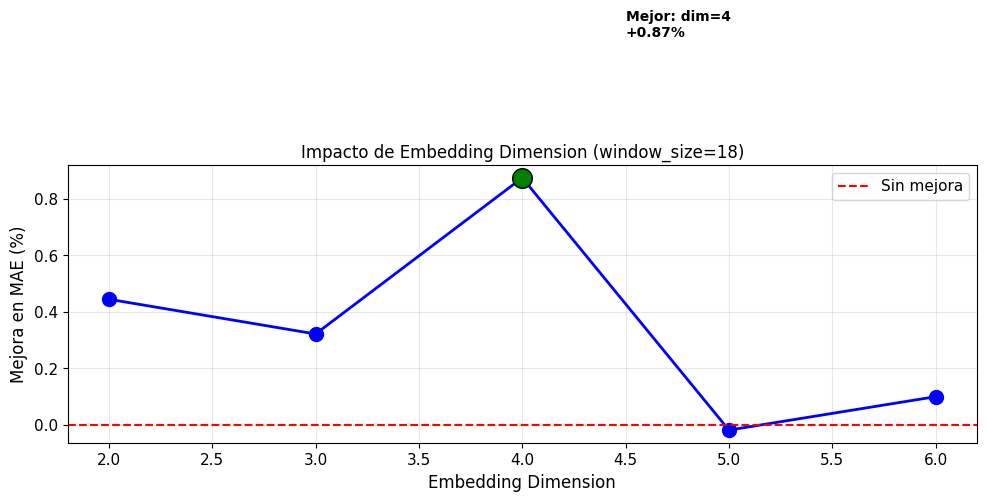


✅ MEJOR EMBEDDING_DIM: 4 (Mejora: +0.87%)


In [10]:
# ============================================================
#  ACTIVIDAD 2: EXPLORAR EMBEDDING_DIM (FIJANDO WINDOW_SIZE ÓPTIMO)
# ============================================================

print("="*80)
print("🔬 ACTIVIDAD 2: ¿CUÁL ES LA MEJOR DIMENSIÓN DE EMBEDDING?")
print("="*80)

# Usar el mejor window_size encontrado
MEJOR_WINDOW = mejor_window

print(f"Fijando window_size = {MEJOR_WINDOW} meses")
print("\nProbando diferentes embedding_dim (τ=1):")
print("-"*60)

embedding_dims = [2, 3, 4, 5, 6]
resultados_dims = []

for dim in embedding_dims:
    print(f"\nProbando embedding_dim = {dim}...")
    
    # Verificar factibilidad
    min_points = (dim - 1) * 1 + 1
    if min_points > MEJOR_WINDOW:
        print(f"   ⚠ ADVERTENCIA: dim={dim} requiere {min_points} puntos, ventana={MEJOR_WINDOW}")
    
    tda = entrenar_y_evaluar(signal_entreno, signal_prueba,
                             window_size=MEJOR_WINDOW, 
                             embedding_dim=dim, time_delay=1,
                             use_tda=True)
    
    # Baseline con mismo window_size
    base = entrenar_y_evaluar(signal_entreno, signal_prueba,
                              window_size=MEJOR_WINDOW, use_tda=False)
    
    mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
    
    resultados_dims.append({
        'dim': dim,
        'tda_mae': tda['mae'],
        'mejora': mejora
    })
    
    print(f"   TDA MAE: {tda['mae']:.4f}")
    print(f"   Mejora:  {mejora:+.2f}%")

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))

dims = [r['dim'] for r in resultados_dims]
mejoras_dim = [r['mejora'] for r in resultados_dims]

ax.plot(dims, mejoras_dim, 'bo-', linewidth=2, markersize=10)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Sin mejora')
ax.set_xlabel('Embedding Dimension', fontsize=12)
ax.set_ylabel('Mejora en MAE (%)', fontsize=12)
ax.set_title(f'Impacto de Embedding Dimension (window_size={MEJOR_WINDOW})', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()

# Marcar mejor dimensión
best_idx = np.argmax(mejoras_dim)
ax.scatter([dims[best_idx]], [mejoras_dim[best_idx]], c='green', s=200, zorder=5, edgecolors='black')
ax.annotate(f'Mejor: dim={dims[best_idx]}\n{mejoras_dim[best_idx]:+.2f}%', 
            xy=(dims[best_idx], mejoras_dim[best_idx]), 
            xytext=(dims[best_idx]+0.5, mejoras_dim[best_idx]+0.5),
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ MEJOR EMBEDDING_DIM: {dims[best_idx]} (Mejora: {mejoras_dim[best_idx]:+.2f}%)")

In [11]:
# ============================================================
#  PREGUNTA: ¿QUÉ EMBEDDINGS FUNCIONAN MEJOR?
# ============================================================

print("="*80)
print(" PREGUNTA: INTERPRETACIÓN DE EMBEDDING_DIM")
print("="*80)

print(f"""
Resultados:
   - Mejor embedding_dim = {dims[best_idx]}
   - Mejora obtenida = {mejoras_dim[best_idx]:+.2f}%

ANÁLISIS:

1. ¿Qué dimensión de embedding dio la mejor mejora?
   
2. ¿Por qué las dimensiones muy altas (5-6) empeoran el rendimiento?
   (Pista: piensa en la relación (dim-1)*τ+1 ≤ window_size)
   
3. ¿Qué significa que una dimensión pequeña funcione mejor para forecasting?
   
4. La regla práctica dice: embedding_dim ≤ window_size/3
   ¿Se cumple en tu caso? ¿Por qué es importante esta regla?
   

REFLEXIÓN:
   ¿Cuál es el balance entre tener suficiente información (dim grande)
   y evitar el sobreajuste (dim pequeña)?
   - 
""")

 PREGUNTA: INTERPRETACIÓN DE EMBEDDING_DIM

Resultados:
   - Mejor embedding_dim = 4
   - Mejora obtenida = +0.87%

ANÁLISIS:

1. ¿Qué dimensión de embedding dio la mejor mejora?

2. ¿Por qué las dimensiones muy altas (5-6) empeoran el rendimiento?
   (Pista: piensa en la relación (dim-1)*τ+1 ≤ window_size)

3. ¿Qué significa que una dimensión pequeña funcione mejor para forecasting?

4. La regla práctica dice: embedding_dim ≤ window_size/3
   ¿Se cumple en tu caso? ¿Por qué es importante esta regla?


REFLEXIÓN:
   ¿Cuál es el balance entre tener suficiente información (dim grande)
   y evitar el sobreajuste (dim pequeña)?
   - 



🔬 ACTIVIDAD 3: ¿CUÁL ES EL MEJOR RETARDO (τ)?
Fijando window_size = 18, embedding_dim = 4

Probando diferentes time_delays:
------------------------------------------------------------

Probando τ = 1...
   TDA MAE: 37.1575
   Mejora:  +0.87%

Probando τ = 2...
   TDA MAE: 37.2447
   Mejora:  +0.64%

Probando τ = 3...
   TDA MAE: 37.3137
   Mejora:  +0.46%

Probando τ = 4...
   TDA MAE: 37.3468
   Mejora:  +0.37%

Probando τ = 5...
   TDA MAE: 37.3632
   Mejora:  +0.33%


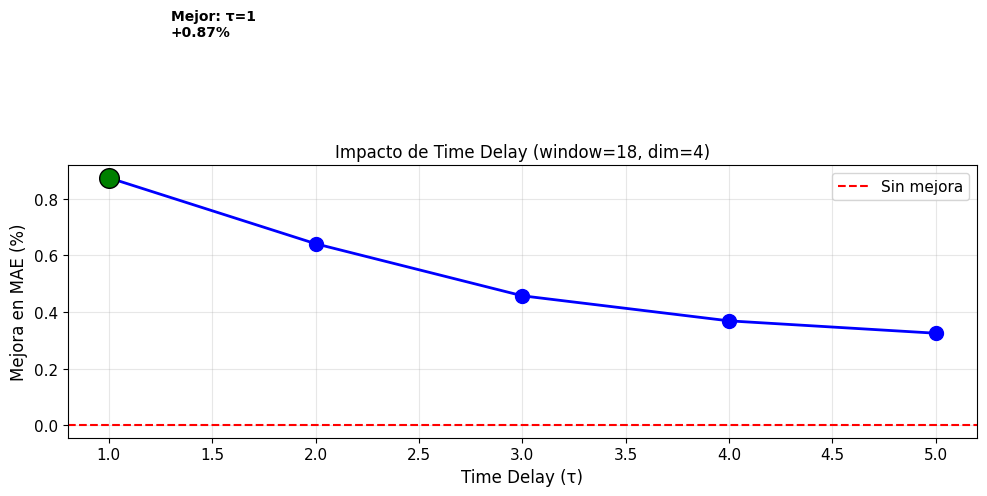


✅ MEJOR TIME_DELAY: τ=1 (Mejora: +0.87%)


In [12]:
# ============================================================
# ACTIVIDAD 3: EXPLORAR TIME_DELAY
# ============================================================

print("="*80)
print("🔬 ACTIVIDAD 3: ¿CUÁL ES EL MEJOR RETARDO (τ)?")
print("="*80)

# Usar mejor window_size y embedding_dim
MEJOR_DIM = dims[best_idx]

print(f"Fijando window_size = {MEJOR_WINDOW}, embedding_dim = {MEJOR_DIM}")
print("\nProbando diferentes time_delays:")
print("-"*60)

time_delays = [1, 2, 3, 4, 5]
resultados_delays = []

for delay in time_delays:
    print(f"\nProbando τ = {delay}...")
    
    # Verificar factibilidad
    min_points = (MEJOR_DIM - 1) * delay + 1
    if min_points > MEJOR_WINDOW:
        print(f"   ⚠ ADVERTENCIA: τ={delay} requiere {min_points} puntos, ventana={MEJOR_WINDOW}")
        print(f"   → El embedding no será válido")
        continue
    
    tda = entrenar_y_evaluar(signal_entreno, signal_prueba,
                             window_size=MEJOR_WINDOW, 
                             embedding_dim=MEJOR_DIM, time_delay=delay,
                             use_tda=True)
    
    # Baseline con mismo window_size
    base = entrenar_y_evaluar(signal_entreno, signal_prueba,
                              window_size=MEJOR_WINDOW, use_tda=False)
    
    mejora = (base['mae'] - tda['mae']) / base['mae'] * 100
    
    resultados_delays.append({
        'delay': delay,
        'tda_mae': tda['mae'],
        'mejora': mejora,
        'valido': True
    })
    
    print(f"   TDA MAE: {tda['mae']:.4f}")
    print(f"   Mejora:  {mejora:+.2f}%")

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))

if resultados_delays:
    delays = [r['delay'] for r in resultados_delays]
    mejoras_delay = [r['mejora'] for r in resultados_delays]
    
    ax.plot(delays, mejoras_delay, 'bo-', linewidth=2, markersize=10)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Sin mejora')
    ax.set_xlabel('Time Delay (τ)', fontsize=12)
    ax.set_ylabel('Mejora en MAE (%)', fontsize=12)
    ax.set_title(f'Impacto de Time Delay (window={MEJOR_WINDOW}, dim={MEJOR_DIM})', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Marcar mejor delay
    best_idx_delay = np.argmax(mejoras_delay)
    ax.scatter([delays[best_idx_delay]], [mejoras_delay[best_idx_delay]], 
               c='green', s=200, zorder=5, edgecolors='black')
    ax.annotate(f'Mejor: τ={delays[best_idx_delay]}\n{mejoras_delay[best_idx_delay]:+.2f}%', 
                xy=(delays[best_idx_delay], mejoras_delay[best_idx_delay]), 
                xytext=(delays[best_idx_delay]+0.3, mejoras_delay[best_idx_delay]+0.5),
                fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ MEJOR TIME_DELAY: τ={delays[best_idx_delay]} (Mejora: {mejoras_delay[best_idx_delay]:+.2f}%)")
else:
    print("No se obtuvieron resultados válidos. Reduce embedding_dim o aumenta window_size.")

In [13]:
# ============================================================
# PREGUNTA: ¿QUÉ SIGNIFICA EL TIME_DELAY?
# ============================================================

print("="*80)
print("PREGUNTA : INTERPRETACIÓN DEL TIME_DELAY")
print("="*80)

if resultados_delays:
    mejor_delay = delays[best_idx_delay]
    print(f"""
Resultados:
   - Mejor τ = {mejor_delay}
   - Mejora obtenida = {mejoras_delay[best_idx_delay]:+.2f}%

ANÁLISIS:

1. ¿Qué time_delay funcionó mejor? ¿τ=1 o τ>1?
   
2. τ=1 significa tomar puntos consecutivos. ¿Por qué esto funciona mejor
   para forecasting a corto plazo?
   
3. ¿Qué información perderías si usaras τ=3 o τ=4?
   
4. ¿En qué tipo de series temporales crees que τ>1 podría ser mejor?
   

REFLEXIÓN:
   ¿Cuál es la relación entre time_delay y la frecuencia de muestreo
   (datos mensuales en este caso)?
   - 
""")

PREGUNTA : INTERPRETACIÓN DEL TIME_DELAY

Resultados:
   - Mejor τ = 1
   - Mejora obtenida = +0.87%

ANÁLISIS:

1. ¿Qué time_delay funcionó mejor? ¿τ=1 o τ>1?

2. τ=1 significa tomar puntos consecutivos. ¿Por qué esto funciona mejor
   para forecasting a corto plazo?

3. ¿Qué información perderías si usaras τ=3 o τ=4?

4. ¿En qué tipo de series temporales crees que τ>1 podría ser mejor?


REFLEXIÓN:
   ¿Cuál es la relación entre time_delay y la frecuencia de muestreo
   (datos mensuales en este caso)?
   - 



EXPERIMENTO FINAL: VALIDACIÓN DE PARÁMETROS ÓPTIMOS

    PARÁMETROS ENCONTRADOS:
    ┌─────────────────────────────────────────────────────────────┐
    │  window_size    = 18 meses (1 año)                    │
    │  embedding_dim  = 4                                   │
    │  time_delay     = 1                                   │
    └─────────────────────────────────────────────────────────────┘
    

📊 COMPARACIÓN FINAL:
   Métrica    Sin TDA      Con TDA (opt)   Mejora    
   --------------------------------------------------
   MAE        37.4852     37.1575           +0.87%
   R²          -0.3561     -0.3430           +0.0131


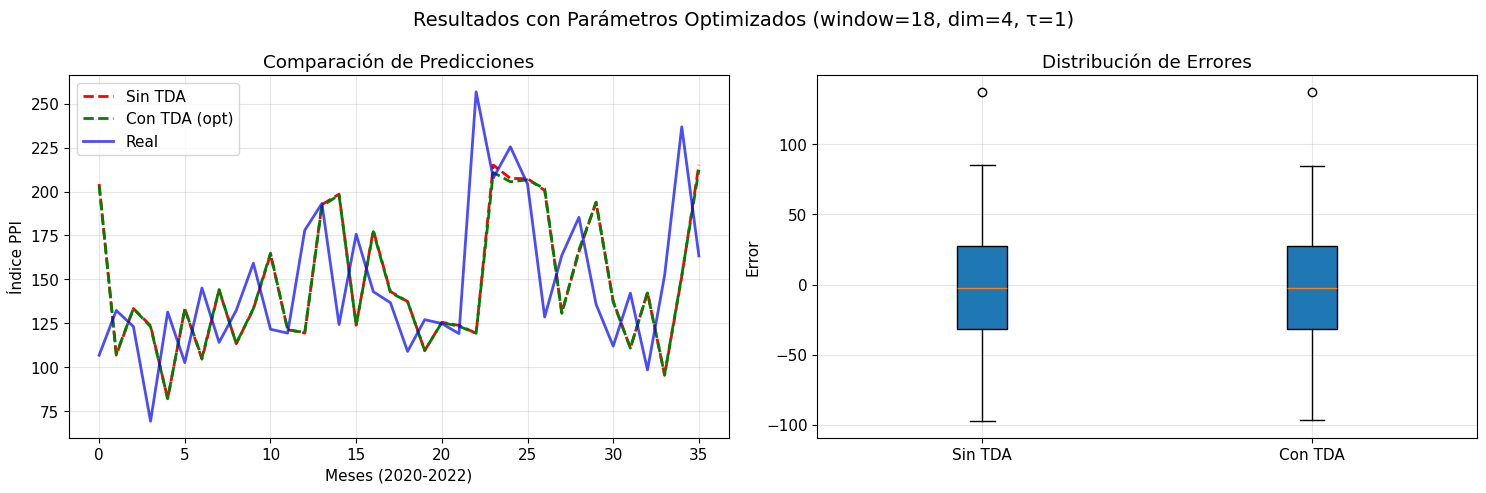

In [14]:
# ============================================================
# EXPERIMENTO FINAL: VALIDACIÓN CON MEJORES PARÁMETROS
# ============================================================

print("="*80)
print("EXPERIMENTO FINAL: VALIDACIÓN DE PARÁMETROS ÓPTIMOS")
print("="*80)

if resultados_delays:
    OPTIMAL_WINDOW = MEJOR_WINDOW
    OPTIMAL_DIM = MEJOR_DIM
    OPTIMAL_DELAY = delays[best_idx_delay]
    
    print(f"""
    PARÁMETROS ENCONTRADOS:
    ┌─────────────────────────────────────────────────────────────┐
    │  window_size    = {OPTIMAL_WINDOW} meses ({OPTIMAL_WINDOW//12} año)                    │
    │  embedding_dim  = {OPTIMAL_DIM}                                   │
    │  time_delay     = {OPTIMAL_DELAY}                                   │
    └─────────────────────────────────────────────────────────────┘
    """)
    
    # Evaluar con parámetros óptimos
    resultado_optimo = entrenar_y_evaluar(signal_entreno, signal_prueba,
                                          window_size=OPTIMAL_WINDOW,
                                          embedding_dim=OPTIMAL_DIM,
                                          time_delay=OPTIMAL_DELAY,
                                          use_tda=True)
    
    resultado_base_final = entrenar_y_evaluar(signal_entreno, signal_prueba,
                                              window_size=OPTIMAL_WINDOW,
                                              use_tda=False)
    
    mejora_final = (resultado_base_final['mae'] - resultado_optimo['mae']) / resultado_base_final['mae'] * 100
    
    print(f"\n📊 COMPARACIÓN FINAL:")
    print(f"   {'Métrica':<10} {'Sin TDA':<12} {'Con TDA (opt)':<15} {'Mejora':<10}")
    print(f"   {'-'*50}")
    print(f"   {'MAE':<10} {resultado_base_final['mae']:.4f}     {resultado_optimo['mae']:.4f}           {mejora_final:+.2f}%")
    print(f"   {'R²':<10}  {resultado_base_final['r2']:.4f}     {resultado_optimo['r2']:.4f}           {(resultado_optimo['r2'] - resultado_base_final['r2']):+.4f}")
    
    # Visualización final
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Predicciones
    ax1 = axes[0]
    ax1.plot(resultado_base_final['preds'], 'r--', label='Sin TDA', linewidth=2)
    ax1.plot(resultado_optimo['preds'], 'g--', label=f'Con TDA (opt)', linewidth=2)
    ax1.plot(signal_prueba, 'b-', label='Real', linewidth=2, alpha=0.7)
    ax1.set_xlabel('Meses (2020-2022)')
    ax1.set_ylabel('Índice PPI')
    ax1.set_title('Comparación de Predicciones')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Errores
    ax2 = axes[1]
    errores_base = signal_prueba - resultado_base_final['preds']
    errores_opt = signal_prueba - resultado_optimo['preds']
    ax2.boxplot([errores_base, errores_opt], labels=['Sin TDA', 'Con TDA'], patch_artist=True)
    ax2.set_ylabel('Error')
    ax2.set_title('Distribución de Errores')
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(f'Resultados con Parámetros Optimizados (window={OPTIMAL_WINDOW}, dim={OPTIMAL_DIM}, τ={OPTIMAL_DELAY})', fontsize=14)
    plt.tight_layout()
    plt.show()

In [15]:
# ============================================================
# PREGUNTA FINAL: REFLEXIÓN SOBRE EL PROCESO
# ============================================================

print("="*80)
print("PREGUNTA: REFLEXIÓN FINAL")
print("="*80)

print("""
Has completado la optimización de parámetros para forecasting con TDA.

REFLEXIONA SOBRE EL PROCESO:

1. ¿Qué parámetro tuvo el mayor impacto en la mejora """)

PREGUNTA: REFLEXIÓN FINAL

Has completado la optimización de parámetros para forecasting con TDA.

REFLEXIONA SOBRE EL PROCESO:

1. ¿Qué parámetro tuvo el mayor impacto en la mejora 
